## Initial Set-up for Google Drive

In [1]:
import os
from google.colab import drive

drive.mount('/content/drive')

ROOT_DIR = '/content/drive/MyDrive/CIFAR Image Generator'
DATA_DIR = os.path.join(ROOT_DIR, 'data')
SAMPLES_DIR = os.path.join(ROOT_DIR, 'samples')
MODELS_DIR = os.path.join(ROOT_DIR, 'models')
LOGS_DIR = os.path.join(ROOT_DIR, 'logs')

Mounted at /content/drive


## Notebook-wide Constants

In [2]:
RANDOM_SEED = 42
NUM_WORKERS = 4

NUM_EPOCHS = 1
NUM_TIMESTEPS = 1000

BATCH_SIZE = 512
EMBEDDING_DIM = 256
BASE_CHANNELS = 128

LEARNING_RATE = 2e-4
BETA_START = 1e-4
BETA_END = 2e-2

SyntaxError: invalid syntax (ipython-input-3978985033.py, line 1)

In [ ]:

import random
import numpy as np
import torch

def seed_everything(seed=42):
  random.seed(RANDOM_SEED)
  np.random.seed(RANDOM_SEED)
  torch.manual_seed(RANDOM_SEED)
  torch.cuda.manual_seed(RANDOM_SEED)
  torch.backends.cudnn.deterministic = True
  torch.backends.cudnn.benchmark = False # slower, but deterministic

seed_everything(RANDOM_SEED)

## Getting the Data and Creating a Dataloader

In [ ]:
import os
import math
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from datetime import datetime

import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F

from torchvision.datasets import CIFAR10
from torchvision import transforms
from torch.utils.data import DataLoader
from torch.optim import Adam


!pip install ipywidgets
!jupyter nbextension enable --py widgetsnbextension

from tqdm.notebook import tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 79.6 MB/s eta 0:00:00
Enabling notebook extension jupyter-js-widgets/extension...
      - Validating: OK


In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_set = CIFAR10(
    root=DATA_DIR,
    train=True,
    download=True,
    transform=transform
)
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)

test_set = CIFAR10(
    root=DATA_DIR,
    train=False,
    download=True,
    transform=transform
)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

#### Visualizing the Data

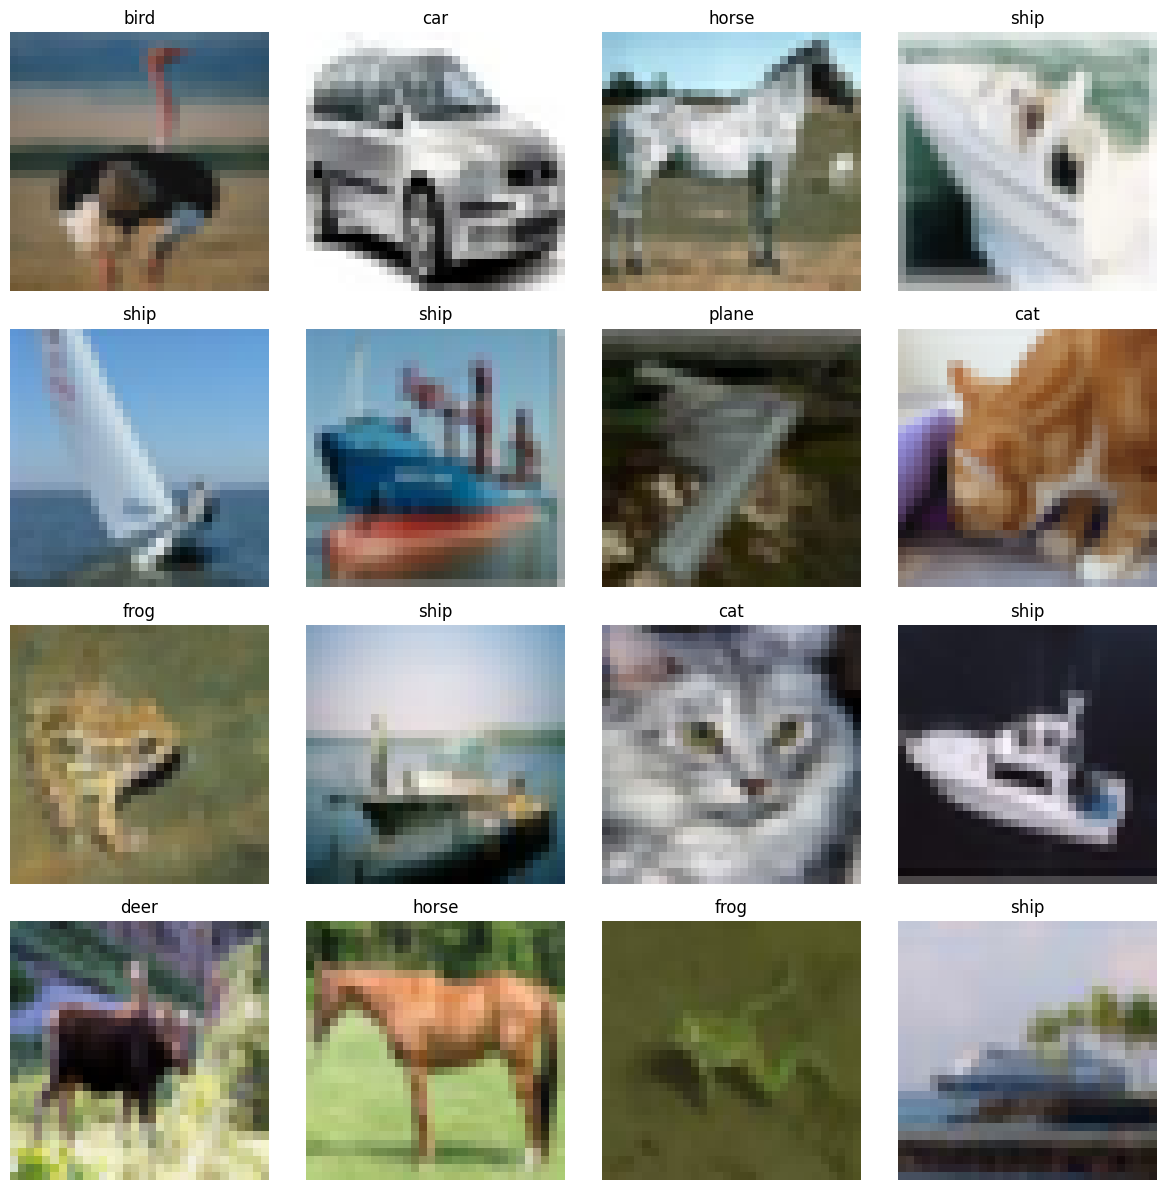

In [ ]:
class_names = ['plane', 'car', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

indices = torch.randperm(len(train_set))[:16]

fig, axes = plt.subplots(4, 4, figsize=(12, 12))

for i, ax in enumerate(axes.flat):
    idx = indices[i]
    img, label_idx = train_set[idx]

    img = img.permute(1, 2, 0) # (C, H, W) to (H, W, C)
    img = img * 0.5 + 0.5 # De-Normalize
    img = img.numpy().clip(0, 1) # Fix precision errors

    ax.imshow(img)
    ax.set_title(class_names[label_idx])

    ax.axis('off')

plt.tight_layout()
plt.show()

## Creating the U-Net model for the DDPM

In [ ]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels, mid_channels=None):
        super().__init__()

        if not mid_channels:
            mid_channels = out_channels

        self.conv1 = nn.Conv2d(
            in_channels,
            mid_channels,
            kernel_size=3,
            padding=1,
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(mid_channels)

        self.conv2 = nn.Conv2d(
            mid_channels,
            out_channels,
            kernel_size=3,
            padding=1,
            bias=False
        )
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x, t_emb=None):
      h = self.relu(self.bn1(self.conv1(x)))

      if t_emb is not None:
        h = h + t_emb[:, :, None, None]

      h = self.relu(self.bn2(self.conv2(h)))

      return h

In [ ]:
class Downsample(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.maxpool = nn.MaxPool2d(2)
        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x, t_emb):
        # reduce the spatial dimensions by half and then pass through double convolution
        x = self.maxpool(x)
        return self.conv(x, t_emb)


In [ ]:
class Upsample(nn.Module):
    def __init__(self, in_channels, out_channels):
        # currently only using bilinear interpolation for upsampling
        super().__init__()

        self.upsample = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x, skip_connection, t_emb):
        x = self.upsample(x) # doubles the spatial dimensions
        x = torch.cat([skip_connection, x], dim=1) # concatenate with skip connections

        return self.conv(x, t_emb)

In [ ]:
class UNet(nn.Module):
  def __init__(self, n_channels=3, n_classes=3, time_emb_dim=EMBEDDING_DIM, base_channels=BASE_CHANNELS):
    super().__init__()

    self.time_mlp = nn.Sequential(
        nn.Linear(time_emb_dim, time_emb_dim),
        nn.GELU(),
        nn.Linear(time_emb_dim, time_emb_dim)
    )

    # Rename for ease of use
    c = base_channels

    # Encoders
    self.inc = DoubleConv(n_channels, c)
    self.down1 = Downsample(c, c * 2)
    self.down2 = Downsample(c * 2, c * 4)
    self.down3 = Downsample(c * 4, c * 8)

    # Bottleneck
    self.bot = DoubleConv(c * 8, c * 16)

    # Decoders
    self.up1 = Upsample((c * 16) + (c * 4), (c * 4))
    self.up2 = Upsample((c * 4) + (c * 2), (c * 2))
    self.up3 = Upsample(c * 2 + c, c)

    # Output
    self.outc = nn.Conv2d(c, n_classes, kernel_size=1)

    self.time_projections = nn.ModuleList([
        nn.Linear(time_emb_dim, c),    # inc
        nn.Linear(time_emb_dim, c * 2),   # down1
        nn.Linear(time_emb_dim, c * 4),   # down2
        nn.Linear(time_emb_dim, c * 8),   # down3
        nn.Linear(time_emb_dim, c * 16),  # bottleneck
        nn.Linear(time_emb_dim, c * 4),   # up1
        nn.Linear(time_emb_dim, c * 2),   # up2
        nn.Linear(time_emb_dim, c),    # up3
    ])

  def forward(self, x, t):
    t = self.time_mlp(t)

    def get_time(layer_idx, tensor_t):
      return self.time_projections[layer_idx](tensor_t)

    # Downsample block
    x1 = self.inc(x, get_time(0, t))
    x2 = self.down1(x1, get_time(1, t))
    x3 = self.down2(x2, get_time(2, t))
    x4 = self.down3(x3, get_time(3, t))

    # Bottleneck
    x = self.bot(x4, get_time(4, t))

    # Upsample block
    x = self.up1(x, x3, get_time(5, t))
    x = self.up2(x, x2, get_time(6, t))
    x = self.up3(x, x1, get_time(7, t))

    # Final Output
    return self.outc(x)

In [ ]:
class TimeEmbeddings(nn.Module):
    def __init__(self, embedding_dim=EMBEDDING_DIM, max_time=NUM_TIMESTEPS):
        super().__init__()

        self.embedding_dim = embedding_dim
        self.max_time = max_time

        half_dim = embedding_dim // 2
        emb = math.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, dtype=torch.float32) * -emb)
        self.register_buffer('inv_freq', 1 / emb)

    def forward(self, t):
        emb = t[:, None] * self.inv_freq[None, :]
        emb = torch.cat((emb.sin(), emb.cos()), dim=-1)
        return emb

## Implementing the DDPM model

In [ ]:
class DDPM(nn.Module):
    def __init__(self, unet, n_timesteps=NUM_TIMESTEPS, beta_start=BETA_START, beta_end=BETA_END, embedding_dim=EMBEDDING_DIM):
        super().__init__()

        self.unet = unet
        self.n_timesteps = n_timesteps
        self.embedding_dim = embedding_dim

        # Time Embeddings
        self.time_embed = TimeEmbeddings(embedding_dim=embedding_dim, max_time=n_timesteps)

        # Beta Schedule
        self.register_buffer('betas', torch.linspace(beta_start, beta_end, n_timesteps))
        self.register_buffer('alphas', 1.0 - self.betas)
        self.register_buffer('alphas_cumprod', torch.cumprod(self.alphas, dim=0))

        # Setting up the calculations for Forward Diffusion (q)
        self.register_buffer('sqrt_alphas_cumprod', torch.sqrt(self.alphas_cumprod))
        self.register_buffer('sqrt_one_minus_alphas_cumprod', torch.sqrt(1.0 - self.alphas_cumprod))

        # Setting up the calculations for Posterior q(x_{t-1} | x_t, x_0)
        self.register_buffer('sqrt_recip_alphas', torch.sqrt(1.0 / self.alphas))

        posterior_variance = self.betas * (1.0 - torch.cat([torch.tensor([1.0]).to(self.betas.device), self.alphas_cumprod[:-1]])) / (1.0 - self.alphas_cumprod)
        self.register_buffer('posterior_variance', posterior_variance)


    def extract(self, a, t, x_shape):
      batch_size = t.shape[0]
      out = a.to(t.device)[t]
      return out.reshape(batch_size, *((1,) * (len(x_shape) - 1))).to(t.device)

    def forward_sample(self, x_0, t, noise=None):
      if noise is None:
        noise = torch.randn_like(x_0)

      sqrt_alpha_bar_t = self.extract(self.sqrt_alphas_cumprod, t, x_0.shape)
      sqrt_one_minus_alpha_bar_t = self.extract(self.sqrt_one_minus_alphas_cumprod, t, x_0.shape)

      return sqrt_alpha_bar_t * x_0 + sqrt_one_minus_alpha_bar_t * noise


    def reverse_losses(self, x_0, t):
      noise = torch.randn_like(x_0).to(x_0.device)

      # Get noisy image
      x_noisy = self.forward_sample(x_0, t, noise=noise)

      # Get time embedding vector
      t_emb = self.time_embed(t)

      # Predict noise using UNet
      predicted_noise = self.unet(x_noisy, t_emb)

      return F.mse_loss(noise, predicted_noise)


    @torch.no_grad()
    def reverse_sample(self, x, t, t_index):
      betas_t = self.extract(self.betas, t, x.shape)
      sqrt_one_minus_alpha_cumprod_t = self.extract(self.sqrt_one_minus_alphas_cumprod, t, x.shape)
      sqrt_recip_alphas_t = self.extract(self.sqrt_recip_alphas, t, x.shape)

      t_emb = self.time_embed(t)

      model_mean = sqrt_recip_alphas_t * (
          x - (betas_t * self.unet(x, t_emb)) / sqrt_one_minus_alpha_cumprod_t
      )

      if t_index == 0:
        return model_mean

      posterior_variance_t = self.extract(self.posterior_variance, t, x.shape)
      noise = torch.randn_like(x)

      return model_mean + torch.sqrt(posterior_variance_t) * noise


    @torch.no_grad()
    def sample(self, batch_size, device):
      img = torch.randn(batch_size, 3, 32, 32).to(device)

      for i in tqdm(reversed(range(1, self.n_timesteps+1)), desc='Sampling ', total=self.n_timesteps):
        t = torch.full((batch_size,), i-1, dtype=torch.long, device=device)

        img = self.reverse_sample(img, t, i-1)

      return img.clamp(-1, 1)


In [ ]:
def save_images_in_path(images, path):
    if not os.path.exists(path):
        os.makedirs(path)

    for i, img in enumerate(images):
        img = img.permute(1, 2, 0).cpu().numpy()
        img = (img + 1) / 2
        img = (img * 255).astype(np.uint8)

        img = Image.fromarray(img)
        img.save(os.path.join(path, f'image_{i}.png'))

In [ ]:
def train_ddpm(ddpm, train_loader, num_epochs, device, lr=LEARNING_RATE):
    optimizer = Adam(ddpm.parameters(), lr=lr)

    loss_history = []

    for epoch in range(num_epochs):
        pbar = tqdm(train_loader, desc=f'Epoch {epoch + 1}/{num_epochs}')
        ddpm.train()
        total_loss = 0.0


        batch_losses = []
        for batch in pbar:
            x, _ = batch
            x = x.to(device)

            optimizer.zero_grad()

            t = torch.randint(0, ddpm.n_timesteps, (x.shape[0],), device=device).long()
            loss = ddpm.reverse_losses(x, t)

            loss.backward()
            optimizer.step()

            batch_losses.append(loss.item())
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})


        epoch_avg_loss = sum(batch_losses) / len(batch_losses)
        loss_history.append(epoch_avg_loss)

        # SAMPLE EVERY 5 EPOCHS
        if (epoch + 1) % 5 == 0 or (epoch + 1) == num_epochs:
            ddpm.eval()
            with torch.no_grad():
                samples = ddpm.sample(32, device) # sample 32 images for the grid

            save_path = os.path.join(SAMPLES_DIR, f'sample_{epoch+1}.png')
            save_images_in_path(samples, save_path)

    return epoch_avg_loss, optimizer, loss_history

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

unet = UNet(n_channels=3, n_classes=3).to(device)
ddpm = DDPM(unet).to(device)

final_loss, optimizer, loss_history = train_ddpm(ddpm, train_loader, NUM_EPOCHS, device)

Epoch 1/1:   0%|          | 0/98 [00:00<?, ?it/s]

Sampling :   0%|          | 0/1000 [00:00<?, ?it/s]

In [ ]:
def show_batch_of_images(images):
    images = images.clamp(-1, 1)
    images = (images + 1) / 2
    grid = torchvision.utils.make_grid(images, nrow=4, pad_value=1).to('cpu')
    plt.figure(figsize=(15, 15))
    plt.imshow(grid.permute(1, 2, 0))
    plt.axis('off')
    plt.show()

Sampling :   0%|          | 0/1000 [00:00<?, ?it/s]

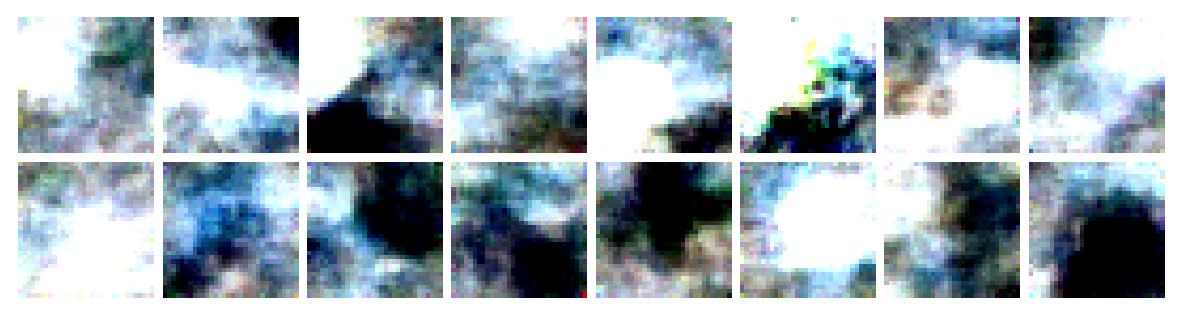

In [ ]:
samples = ddpm.sample(16, device)
final_sample_path = os.path.join(SAMPLES_DIR, 'final_samples')
save_images_in_path(samples, final_sample_path)
show_batch_of_images(samples)

In [ ]:
def save_model_version(model, optimizer, epoch, base_channels, loss, config, save_dir):
    os.makedirs(save_dir, exist_ok=True)

    timestamp = datetime.now().strftime("%Y%m%d_%H%M")
    model_name = f"ddpm_{config['dataset']}_e{epoch}_c{base_channels}_loss{loss:.4f}_{timestamp}.pt"
    save_path = os.path.join(save_dir, model_name)


    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(), # Useful for resuming training later
        'loss': loss,
        'timestamp': timestamp,
        'config': config
    }

    torch.save(checkpoint, save_path)
    print(f"Model saved to: {save_path}")
    return save_path

In [ ]:
model_config = {
    'dataset': "CIFAR10",
    'image_size': 32,
    'n_channels': 3,
    'n_classes': 10,
    'n_timesteps': NUM_TIMESTEPS,
    'time_emb_dim': EMBEDDING_DIM,
    'lr': LEARNING_RATE,
    'batch_size': BATCH_SIZE,
    'num_epochs': NUM_EPOCHS,
    'loss_history': loss_history
}

save_model_version(
    model=ddpm,
    optimizer=optimizer,
    epoch=NUM_EPOCHS,
    base_channels=BASE_CHANNELS,
    loss=final_loss,
    config=model_config,
    save_dir=MODELS_DIR
)

Model saved to: /content/drive/MyDrive/CIFAR Image Generator/models/ddpm_CIFAR10_e1_c128_loss0.1598_20260127_0841.pt


'/content/drive/MyDrive/CIFAR Image Generator/models/ddpm_CIFAR10_e1_c128_loss0.1598_20260127_0841.pt'